# Homework 4

This file contains code to solve problems on Homework 4 issued by Akil Narayan.

### Problem 2.20

Use the Yale Face Database dataset on Kaggle, or an equivalent labeled face dataset, for the following reproducible experiments. State the dataset, preprocessing, selected observations, values of 𝑘, and error measure.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

SEED = 0

In [5]:
rng = np.random.default_rng(SEED)

# Load data
faces = fetch_olivetti_faces(shuffle=True, random_state=SEED)

images = faces.images          # shape: (400, 64, 64)
labels = faces.target          # subject labels 0,...,39
n_images, h, w = images.shape

1. Treat each of several grayscale images separately as a matrix. Plot rank-𝑘 truncated-SVD approximations for several 𝑘 and report the reconstruction error. This is image compression by low-rank SVD, not PCA.

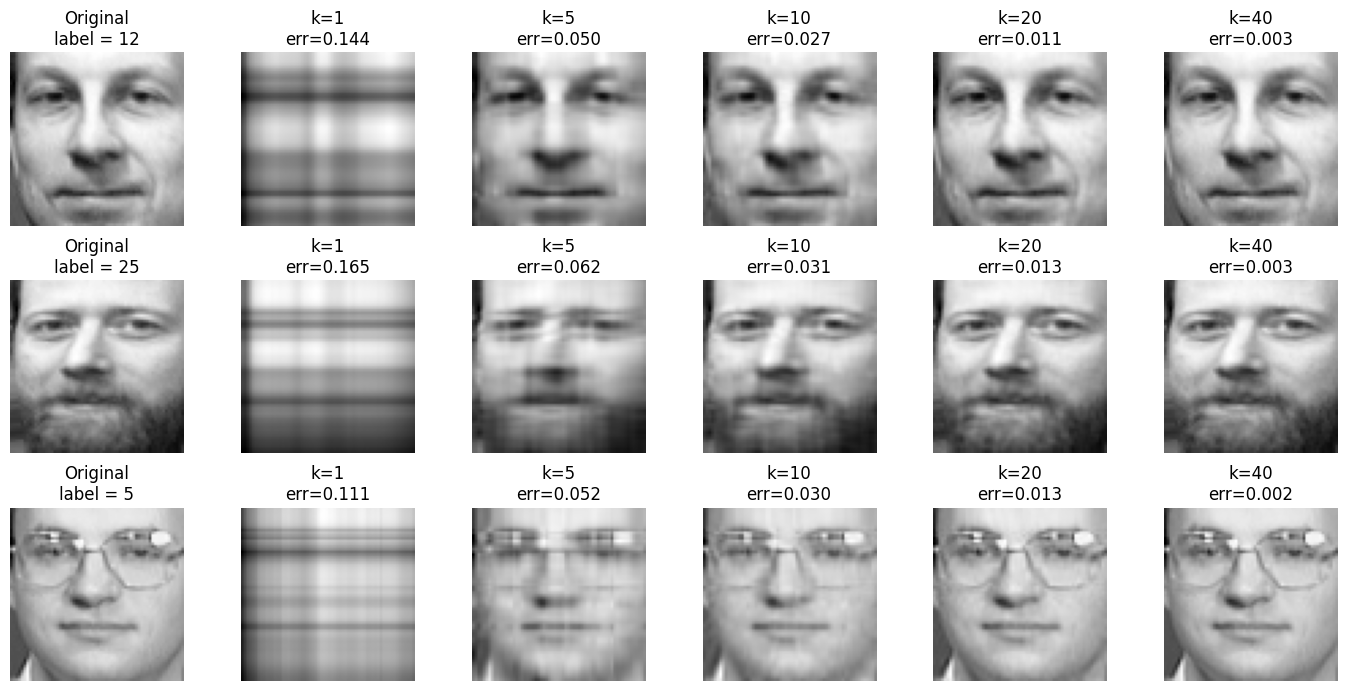

In [6]:
chosen_idx = rng.choice(n_images, size=3, replace=False)
k_svd = [1, 5, 10, 20, 40]

def truncated_svd(A, k):
    """Return rank-k SVD approximation of image matrix A."""
    U, s, VT = np.linalg.svd(A, full_matrices=False)
    return (U[:, :k] * s[:k]) @ VT[:k, :]

def relative_frobenius_error(A, A_k):
    return np.linalg.norm(A - A_k, "fro") / np.linalg.norm(A, "fro")

# Plot original images and their low-rank approximations
fig, axes = plt.subplots(len(chosen_idx), len(k_svd) + 1,
                         figsize=(14, 7))

for row, idx in enumerate(chosen_idx):
    A = images[idx]

    axes[row, 0].imshow(A, cmap="gray")
    axes[row, 0].set_title(f"Original\nlabel = {labels[idx]}")
    axes[row, 0].axis("off")

    for col, k in enumerate(k_svd, start=1):
        A_k = truncated_svd(A, k)
        err = relative_frobenius_error(A, A_k)

        axes[row, col].imshow(A_k, cmap="gray")
        axes[row, col].set_title(f"k={k}\nerr={err:.3f}")
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [8]:
for idx in chosen_idx:
    A = images[idx]
    print(f"\nImage {idx}, subject label {labels[idx]}")
    
    for k in k_svd:
        A_k = truncated_svd(A, k)
        err = relative_frobenius_error(A, A_k)
        print(f"k = {k:2d}, relative Frobenius error = {err:.6f}")


Image 237, subject label 12
k =  1, relative Frobenius error = 0.143629
k =  5, relative Frobenius error = 0.049698
k = 10, relative Frobenius error = 0.026881
k = 20, relative Frobenius error = 0.010881
k = 40, relative Frobenius error = 0.002535

Image 272, subject label 25
k =  1, relative Frobenius error = 0.165280
k =  5, relative Frobenius error = 0.061667
k = 10, relative Frobenius error = 0.031356
k = 20, relative Frobenius error = 0.012561
k = 40, relative Frobenius error = 0.003201

Image 6, subject label 5
k =  1, relative Frobenius error = 0.111312
k =  5, relative Frobenius error = 0.051976
k = 10, relative Frobenius error = 0.030077
k = 20, relative Frobenius error = 0.012838
k = 40, relative Frobenius error = 0.002458


Now we will fit PCA to these faces, using code provided by Braxton Osting in my MATH 5750: Math of Data Science class that I am also enrolled in this semester.

2. Vectorize a collection of images as columns of a data matrix, subtract the sample mean, and compute centered rank-𝑘 PCA reconstructions. Compare reconstruction accuracy across several 𝑘 with the single-image experiment.

In [9]:
X = images.reshape(n_images, -1).T

# Center the data
mean_face = X.mean(axis=1, keepdims=True)
X_centered = X - mean_face

# SVD of the centered data matrix
U, s, VT = np.linalg.svd(X_centered, full_matrices=False)

k_pca = [2, 5, 10, 20, 40, 80, 120]
pca_errors = []

for k in k_pca:
    # PCA reconstruction
    X_k = mean_face + U[:, :k] @ (U[:, :k].T @ X_centered)
    
    # Relative reconstruction error over the whole data matrix
    err = np.linalg.norm(X - X_k, "fro") / np.linalg.norm(X - mean_face, "fro")
    pca_errors.append(err)

    print(f"k = {k:3d}, relative centered-PCA error = {err:.6f}")

k =   2, relative centered-PCA error = 0.788627
k =   5, relative centered-PCA error = 0.675400
k =  10, relative centered-PCA error = 0.586225
k =  20, relative centered-PCA error = 0.486456
k =  40, relative centered-PCA error = 0.386413
k =  80, relative centered-PCA error = 0.287588
k = 120, relative centered-PCA error = 0.226497


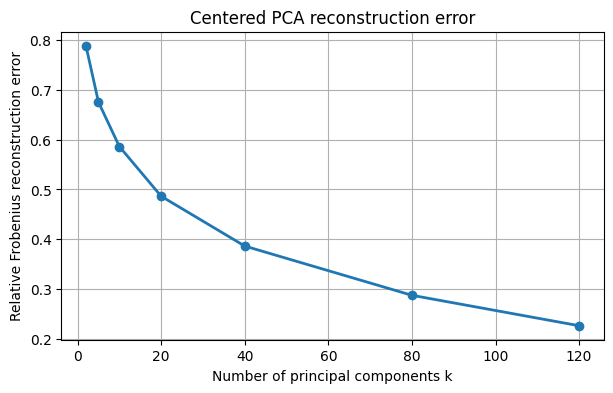

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(k_pca, pca_errors, "o-", linewidth=2)
plt.xlabel("Number of principal components k")
plt.ylabel("Relative Frobenius reconstruction error")
plt.title("Centered PCA reconstruction error")
plt.grid()
plt.show()

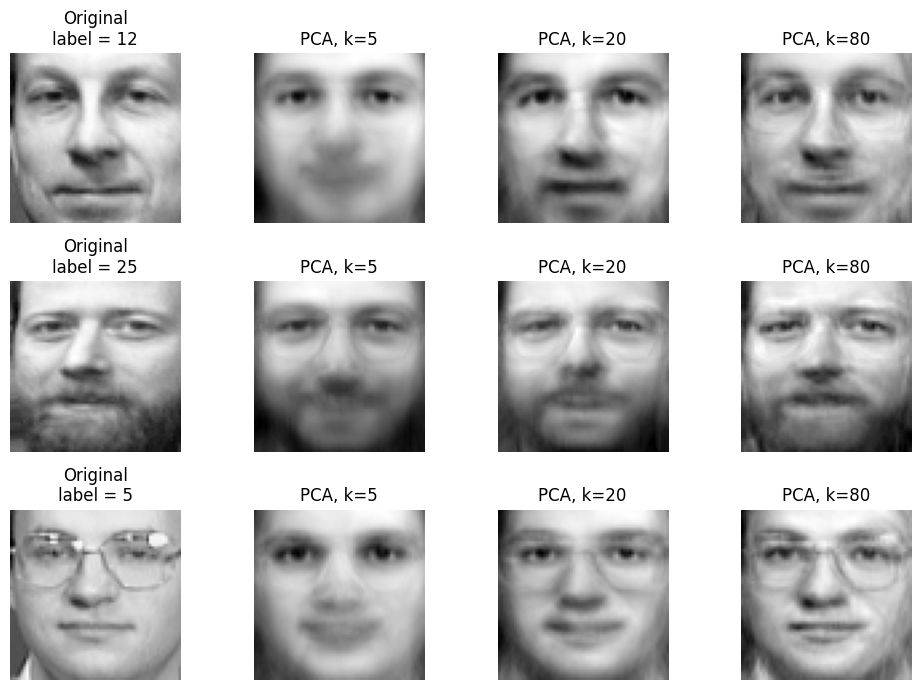

In [11]:
display_idx = chosen_idx
display_k = [5, 20, 80]

fig, axes = plt.subplots(len(display_idx), len(display_k) + 1,
                         figsize=(10, 7))

for row, idx in enumerate(display_idx):
    axes[row, 0].imshow(images[idx], cmap="gray")
    axes[row, 0].set_title(f"Original\nlabel = {labels[idx]}")
    axes[row, 0].axis("off")

    x = X[:, idx:idx+1]

    for col, k in enumerate(display_k, start=1):
        x_k = mean_face + U[:, :k] @ (U[:, :k].T @ (x - mean_face))
        reconstructed_image = x_k.reshape(h, w)

        axes[row, col].imshow(reconstructed_image, cmap="gray")
        axes[row, col].set_title(f"PCA, k={k}")
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

Now we will plot PCA scores

3. Plot the centered PCA scores in two and three dimensions. Describe any visible relationship between the embeddings and available face labels.

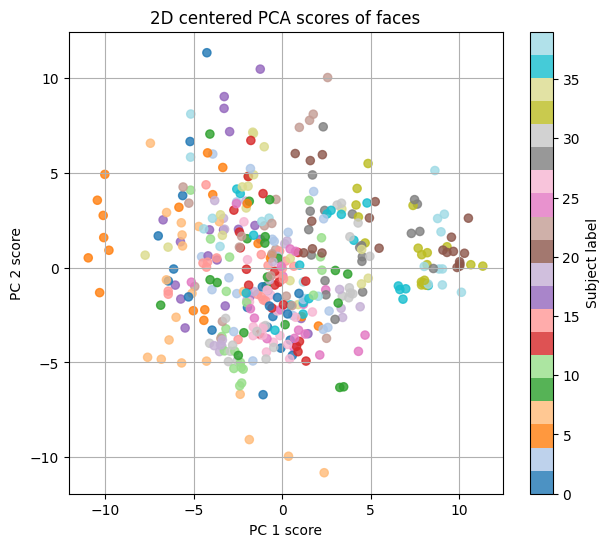

In [12]:
scores = U.T @ X_centered   # shape (400, 400) if interpreted by rows/components

# 2D scores
plt.figure(figsize=(7, 6))
scatter = plt.scatter(scores[0], scores[1],
                      c=labels, cmap="tab20", s=35, alpha=0.8)

plt.xlabel("PC 1 score")
plt.ylabel("PC 2 score")
plt.title("2D centered PCA scores of faces")
plt.colorbar(scatter, label="Subject label")
plt.grid()
plt.show()